# 03 Regularization (Ridge & Lasso) — First Principles

**Goal.** Implement Ridge and Lasso regression from scratch, verify against sklearn,
and explore the bias–variance tradeoff, geometry, and failure cases.

**Prerequisites.** Linear regression, OLS normal equations, polynomial features.

**Theory.** See [theory.md](theory.md) for derivations of closed forms, SVD shrinkage,
subgradients, soft-thresholding, and Bayesian interpretations.

In [1]:
import random

import matplotlib.pyplot as plt
import numpy as np

%load_ext autoreload
%autoreload 2

SEED = 42
random.seed(SEED)
rng = np.random.default_rng(SEED)

## 1. Problem Setup — WHY

Fit a high-degree polynomial to noisy data. OLS coefficients explode as degree
grows, producing wild oscillations on new data.

In [2]:
def true_fn(t):
    return np.sin(2.0 * t)

n_demo = 30
x_demo = np.linspace(-1, 1, n_demo)
y_demo = true_fn(x_demo) + rng.normal(0, 0.15, size=n_demo)

print('degree | max |coef|')
for d in [1, 5, 10, 15]:
    coefs = np.polyfit(x_demo, y_demo, d)
    print(f'{d:>6} | {np.max(np.abs(coefs)):>10.2f}')

degree | max |coef|
     1 |       1.30
     5 |       1.91
    10 |      42.17
    15 |    1688.47


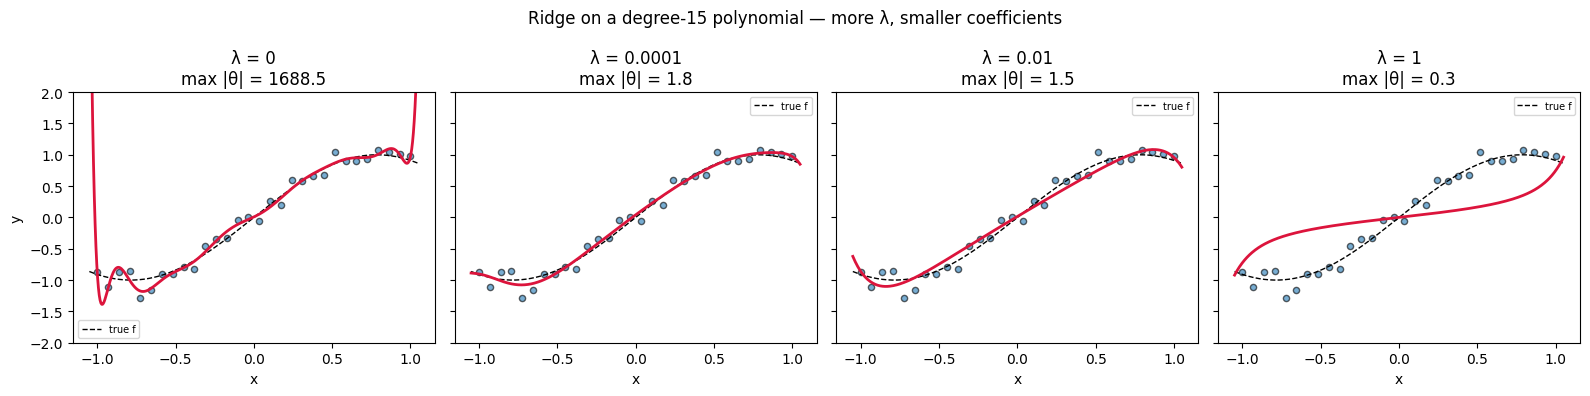

In [3]:
d = 15
Phi = np.vander(x_demo, N=d + 1, increasing=True)
xs = np.linspace(-1.05, 1.05, 400)
Phi_eval = np.vander(xs, N=d + 1, increasing=True)

def ridge_fit_simple(Phi, y, lam):
    n_, p_ = Phi.shape
    A = Phi.T @ Phi + n_ * lam * np.eye(p_)
    return np.linalg.solve(A, Phi.T @ y)

fig, axes = plt.subplots(1, 4, figsize=(16, 4), sharey=True)
for ax, lam in zip(axes, [0.0, 1e-4, 1e-2, 1.0]):
    theta = ridge_fit_simple(Phi, y_demo, lam)
    ax.plot(xs, true_fn(xs), 'k--', lw=1, label='true f')
    ax.scatter(x_demo, y_demo, alpha=0.6, edgecolor='k', s=20)
    ax.plot(xs, Phi_eval @ theta, color='crimson', lw=2)
    ax.set_xlabel('x')
    ax.set_title(f'λ = {lam:g}\nmax |θ| = {np.max(np.abs(theta)):.1f}')
    ax.set_ylim(-2, 2)
    ax.legend(fontsize=7)
axes[0].set_ylabel('y')
plt.suptitle(f'Ridge on a degree-{d} polynomial — more λ, smaller coefficients')
plt.tight_layout()
plt.show()

## 2. Mathematical Core — WHAT

Ridge adds $\lambda\|\theta\|_2^2$; Lasso adds $\lambda\|\theta\|_1$.
See [theory.md](theory.md) for full derivations.

**Key geometric difference:** the L2 constraint is a smooth sphere; the L1 constraint
is a diamond with axis-aligned corners. Tangency at corners produces exact zeros.

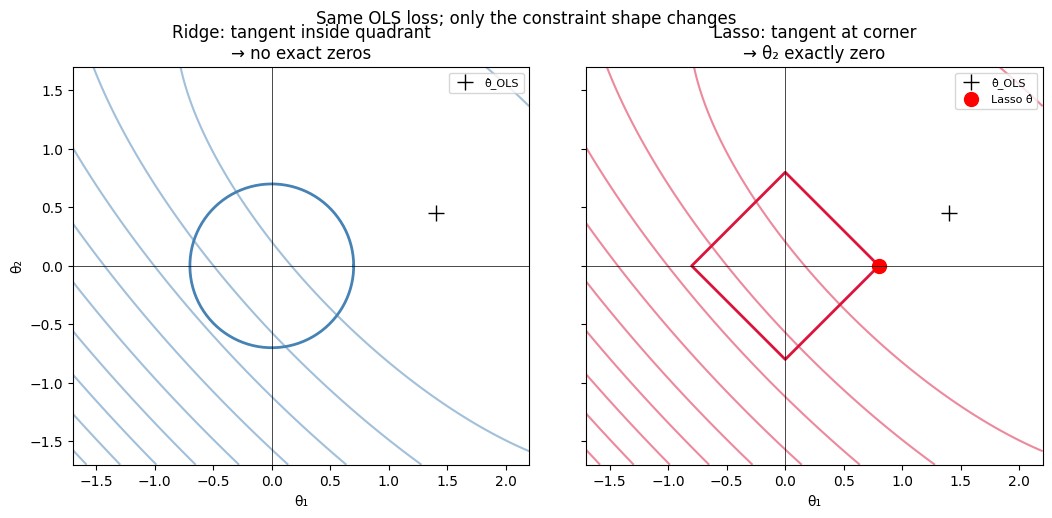

In [4]:
# L1 vs L2 constraint geometry
theta_ols = np.array([1.4, 0.45])
Sigma = np.array([[1.0, 0.7], [0.7, 1.0]])

Ti, Tj = np.meshgrid(np.linspace(-1.7, 2.2, 200), np.linspace(-1.7, 1.7, 200))
diff = np.stack([Ti.ravel() - theta_ols[0], Tj.ravel() - theta_ols[1]], axis=1)
loss_surface = ((diff @ Sigma) * diff).sum(axis=1).reshape(Ti.shape)

fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharey=True)

# Ridge
axes[0].contour(Ti, Tj, loss_surface, levels=10, colors='steelblue', alpha=0.5)
t_angle = np.linspace(0, 2 * np.pi, 200)
r_ridge = 0.7
axes[0].plot(r_ridge * np.cos(t_angle), r_ridge * np.sin(t_angle), color='steelblue', lw=2)
axes[0].plot(*theta_ols, 'k+', markersize=12, label='θ̂_OLS')
axes[0].set_title('Ridge: tangent inside quadrant\n→ no exact zeros')

# Lasso
axes[1].contour(Ti, Tj, loss_surface, levels=10, colors='crimson', alpha=0.5)
r_lasso = 0.8
axes[1].plot([r_lasso, 0, -r_lasso, 0, r_lasso], [0, r_lasso, 0, -r_lasso, 0],
             color='crimson', lw=2)
axes[1].plot(*theta_ols, 'k+', markersize=12, label='θ̂_OLS')
axes[1].plot(r_lasso, 0, 'ro', markersize=10, label='Lasso θ̂')
axes[1].set_title('Lasso: tangent at corner\n→ θ₂ exactly zero')

for ax in axes:
    ax.axhline(0, color='black', lw=0.5)
    ax.axvline(0, color='black', lw=0.5)
    ax.set_aspect('equal')
    ax.set_xlabel('θ₁')
    ax.legend(fontsize=8)
axes[0].set_ylabel('θ₂')
plt.suptitle('Same OLS loss; only the constraint shape changes')
plt.tight_layout()
plt.show()

## 3. Solution Method — HOW

**Ridge:** closed-form solve via $(X^T X + n\lambda I)^{-1} X^T y$.

**Lasso:** coordinate descent — cycle through coordinates, applying
soft-thresholding $S_\lambda(z) = \text{sign}(z)\max(|z| - \lambda, 0)$
at each step.

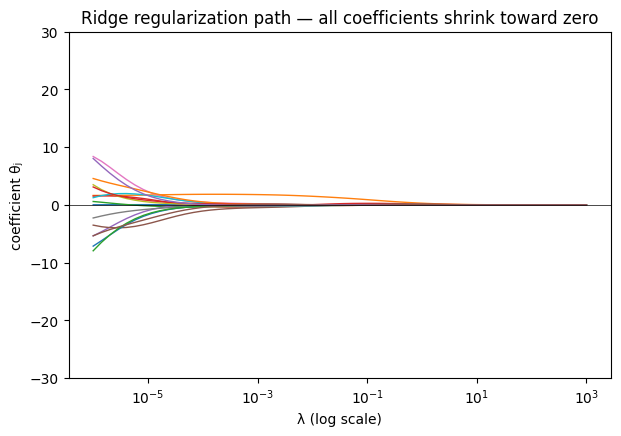

In [5]:
# Ridge regularization path
lams_path = np.logspace(-6, 3, 60)
thetas_path = np.array([ridge_fit_simple(Phi, y_demo, lam) for lam in lams_path])

fig, ax = plt.subplots(figsize=(7, 4.5))
for j in range(d + 1):
    ax.plot(lams_path, thetas_path[:, j], lw=1)
ax.set_xscale('log')
ax.set_xlabel('λ (log scale)')
ax.set_ylabel('coefficient θⱼ')
ax.set_title('Ridge regularization path — all coefficients shrink toward zero')
ax.axhline(0, color='black', lw=0.5)
ax.set_ylim(-30, 30)
plt.show()

## 4. Implementation — BUILD

### 4.1 Ridge from scratch

In [6]:
class RidgeRegressionScratch:
    """Ridge regression with centering trick (unpenalized intercept).

    Convention: L(θ) = (1/n) ‖Xθ − y‖² + lam · ‖θ‖²
    """

    def __init__(self, lam=1.0):
        self.lam = lam

    def fit(self, X, y):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        self.x_mean_ = X.mean(axis=0)
        self.y_mean_ = float(y.mean())
        Xc = X - self.x_mean_
        yc = y - self.y_mean_
        n, p = Xc.shape
        A = Xc.T @ Xc + n * self.lam * np.eye(p)
        self.coef_ = np.linalg.solve(A, Xc.T @ yc)
        self.intercept_ = self.y_mean_ - self.x_mean_ @ self.coef_
        self._Xc_ = Xc
        self._yc_ = yc
        return self

    def predict(self, X):
        return self.intercept_ + np.asarray(X) @ self.coef_

    def hat_diag(self):
        """Diagonal of ridge smoother matrix."""
        Xc = self._Xc_
        n, p = Xc.shape
        A = Xc.T @ Xc + n * self.lam * np.eye(p)
        AinvXt = np.linalg.solve(A, Xc.T)
        slope_leverage = np.einsum('ij,ji->i', Xc, AinvXt)
        return 1.0 / n + slope_leverage

    def loo_press(self):
        """PRESS LOO-CV estimate."""
        r = self._yc_ - self._Xc_ @ self.coef_
        return float(np.mean((r / (1 - self.hat_diag())) ** 2))

In [7]:
# Smoke test
n_test, p_test = 50, 5
X_test = rng.normal(size=(n_test, p_test))
y_test = X_test @ np.arange(1, p_test + 1) + 3.0 + rng.normal(0, 0.2, size=n_test)

rr = RidgeRegressionScratch(lam=0.05).fit(X_test, y_test)
print(f'intercept = {rr.intercept_:.4f}  (true = 3.0)')
print(f'coef      = {rr.coef_}')
print(f'true coef = {np.arange(1, p_test + 1)}')
print(f'PRESS     = {rr.loo_press():.4f}')

intercept = 2.9789  (true = 3.0)
coef      = [0.85101902 1.9438777  2.84746364 3.76763666 4.68018867]
true coef = [1 2 3 4 5]
PRESS     = 0.2453


### 4.2 Lasso from scratch

In [8]:
def soft_thresh(z, t):
    """Soft-thresholding: sign(z) · max(|z| − t, 0)."""
    return np.sign(z) * np.maximum(np.abs(z) - t, 0.0)


class LassoRegressionScratch:
    """Lasso via coordinate descent.

    Convention: L(θ) = (1/n) ‖Xθ − y‖² + lam · ‖θ‖₁
    """

    def __init__(self, lam=0.1, n_sweeps=500, tol=1e-7):
        self.lam = lam
        self.n_sweeps = n_sweeps
        self.tol = tol

    def fit(self, X, y, theta_init=None):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y, dtype=float)
        self.x_mean_ = X.mean(axis=0)
        self.y_mean_ = float(y.mean())
        Xc = X - self.x_mean_
        yc = y - self.y_mean_
        n, p = Xc.shape

        c = (Xc * Xc).sum(axis=0)  # ‖x_j‖² per feature
        theta = np.zeros(p) if theta_init is None else theta_init.copy()
        r = yc - Xc @ theta

        self.n_sweeps_used_ = 0
        for sweep in range(1, self.n_sweeps + 1):
            max_change = 0.0
            for j in range(p):
                if c[j] == 0:
                    continue
                z_j = (Xc[:, j] @ r + c[j] * theta[j]) / c[j]
                new_val = soft_thresh(z_j, n * self.lam / (2 * c[j]))
                delta = new_val - theta[j]
                if delta != 0:
                    r -= Xc[:, j] * delta
                    theta[j] = new_val
                    max_change = max(max_change, abs(delta))
            self.n_sweeps_used_ = sweep
            if max_change < self.tol:
                break

        self.coef_ = theta
        self.intercept_ = self.y_mean_ - self.x_mean_ @ self.coef_
        return self

    def predict(self, X):
        return self.intercept_ + np.asarray(X) @ self.coef_

    def active_set(self, tol=1e-8):
        return np.where(np.abs(self.coef_) > tol)[0]

In [9]:
# Smoke test on sparse signal
n_sp, p_sp = 200, 30
X_sp = rng.normal(size=(n_sp, p_sp))
theta_true = np.zeros(p_sp)
theta_true[:5] = [3.0, -2.0, 1.5, 1.0, -0.8]
y_sp = X_sp @ theta_true + rng.normal(0, 0.5, size=n_sp)

lr = LassoRegressionScratch(lam=0.1).fit(X_sp, y_sp)
print(f'sweeps used   = {lr.n_sweeps_used_}')
print(f'active set    = {lr.active_set()}')
print(f'true non-zero = {np.where(theta_true != 0)[0]}')

sweeps used   = 7
active set    = [0 1 2 3 4 8]
true non-zero = [0 1 2 3 4]


## 5. Library Comparison

In [10]:
try:
    from sklearn.linear_model import Ridge
except ModuleNotFoundError:
    print('scikit-learn not installed; skipping Ridge comparison.')
else:
    print('Ridge comparison (alpha = n * lam):')
    for lam in [0.001, 0.05, 1.0, 100.0]:
        ours = RidgeRegressionScratch(lam=lam).fit(X_test, y_test)
        skl = Ridge(alpha=n_test * lam).fit(X_test, y_test)
        pred_diff = np.max(np.abs(ours.predict(X_test) - skl.predict(X_test)))
        print(f'  λ = {lam:>7g} → max |pred diff| = {pred_diff:.2e}')
        assert pred_diff < 1e-10, f'Ridge mismatch at λ={lam}'

Ridge comparison (alpha = n * lam):
  λ =   0.001 → max |pred diff| = 1.78e-15
  λ =    0.05 → max |pred diff| = 3.55e-15
  λ =       1 → max |pred diff| = 3.55e-15
  λ =     100 → max |pred diff| = 0.00e+00


In [11]:
try:
    from sklearn.linear_model import Lasso
except ModuleNotFoundError:
    print('scikit-learn not installed; skipping Lasso comparison.')
else:
    print('Lasso comparison (alpha = lam / 2):')
    for lam in [0.01, 0.05, 0.2, 1.0]:
        ours = LassoRegressionScratch(lam=lam, tol=1e-10, n_sweeps=10000).fit(X_sp, y_sp)
        skl = Lasso(alpha=lam / 2, tol=1e-10, max_iter=100000).fit(X_sp, y_sp)
        coef_diff = np.max(np.abs(ours.coef_ - skl.coef_))
        n_ours = int(np.sum(np.abs(ours.coef_) > 1e-8))
        n_skl = int(np.sum(np.abs(skl.coef_) > 1e-8))
        print(f'  λ = {lam:>5g} → max |coef diff| = {coef_diff:.2e}  active: {n_ours}/{n_skl}')
        assert coef_diff < 1e-4, f'Lasso mismatch at λ={lam}'

Lasso comparison (alpha = lam / 2):
  λ =  0.01 → max |coef diff| = 8.63e-11  active: 27/27
  λ =  0.05 → max |coef diff| = 4.44e-16  active: 15/15
  λ =   0.2 → max |coef diff| = 4.44e-16  active: 5/5
  λ =     1 → max |coef diff| = 8.88e-16  active: 5/5


## 6. Experiments and Failures — VERIFY

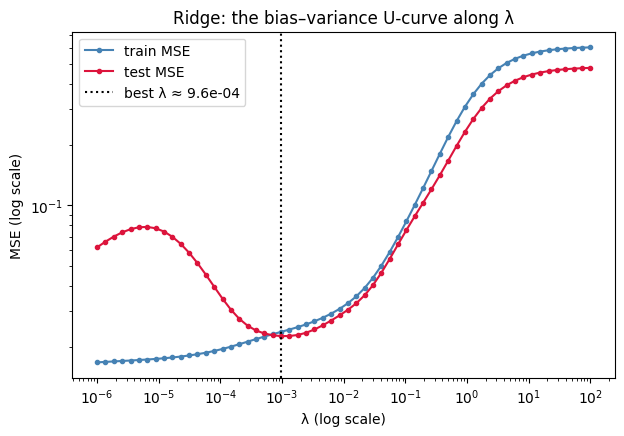

In [12]:
# Train/test U-curve for Ridge
N_curve = 80
x_all = rng.uniform(-1, 1, size=N_curve)
y_all = true_fn(x_all) + rng.normal(0, 0.15, size=N_curve)
perm = rng.permutation(N_curve)
tr_idx, te_idx = perm[:40], perm[40:]
x_tr, y_tr = x_all[tr_idx], y_all[tr_idx]
x_te, y_te = x_all[te_idx], y_all[te_idx]
Phi_tr = np.vander(x_tr, N=d + 1, increasing=True)
Phi_te = np.vander(x_te, N=d + 1, increasing=True)

lams_curve = np.logspace(-6, 2, 60)
mse_tr_list, mse_te_list = [], []
for lam in lams_curve:
    theta = ridge_fit_simple(Phi_tr, y_tr, lam)
    mse_tr_list.append(np.mean((y_tr - Phi_tr @ theta) ** 2))
    mse_te_list.append(np.mean((y_te - Phi_te @ theta) ** 2))
mse_tr_arr, mse_te_arr = np.array(mse_tr_list), np.array(mse_te_list)

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(lams_curve, mse_tr_arr, 'o-', color='steelblue', label='train MSE', markersize=3)
ax.plot(lams_curve, mse_te_arr, 'o-', color='crimson', label='test MSE', markersize=3)
lam_best = lams_curve[np.argmin(mse_te_arr)]
ax.axvline(lam_best, color='black', ls=':', label=f'best λ ≈ {lam_best:.1e}')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('λ (log scale)')
ax.set_ylabel('MSE (log scale)')
ax.set_title('Ridge: the bias–variance U-curve along λ')
ax.legend()
plt.show()

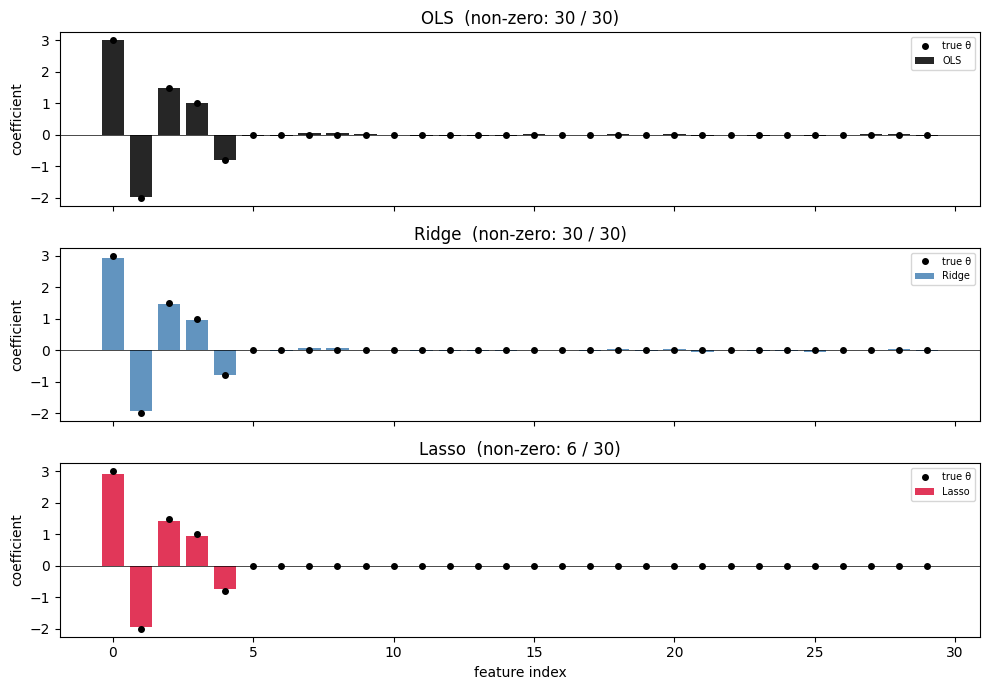

In [13]:
# Lasso variable selection on sparse signal
ols_coefs = np.linalg.lstsq(X_sp, y_sp, rcond=None)[0]
ridge_coefs = RidgeRegressionScratch(lam=0.02).fit(X_sp, y_sp).coef_
lasso_coefs = LassoRegressionScratch(lam=0.1).fit(X_sp, y_sp).coef_

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
for ax, (name, est, c) in zip(
    axes,
    [('OLS', ols_coefs, 'black'), ('Ridge', ridge_coefs, 'steelblue'),
     ('Lasso', lasso_coefs, 'crimson')],
):
    ax.bar(np.arange(p_sp), est, color=c, alpha=0.85, label=name)
    ax.plot(np.arange(p_sp), theta_true, 'ko', markersize=4, label='true θ')
    ax.axhline(0, color='black', lw=0.5)
    ax.set_ylabel('coefficient')
    ax.set_title(f'{name}  (non-zero: {int(np.sum(np.abs(est) > 1e-6))} / {p_sp})')
    ax.legend(fontsize=7)
axes[-1].set_xlabel('feature index')
plt.tight_layout()
plt.show()

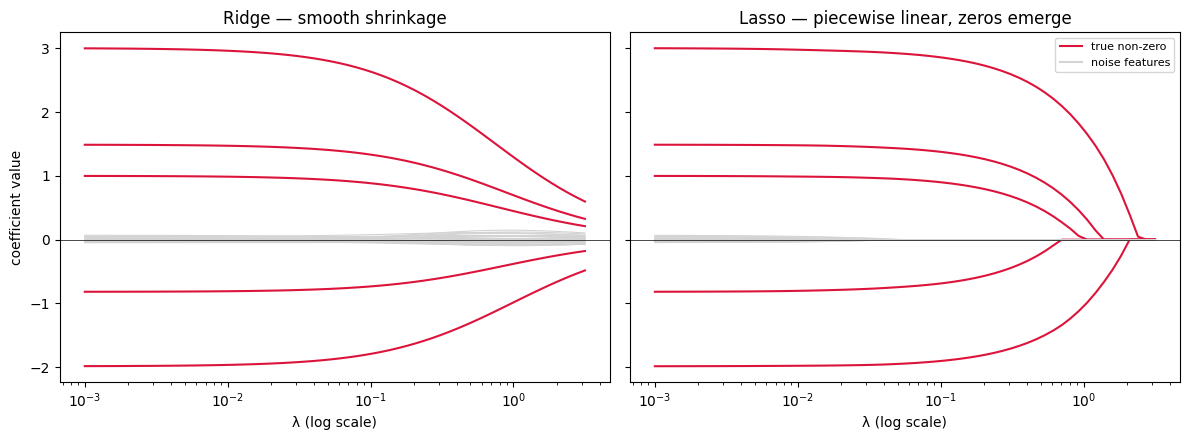

In [14]:
# Ridge vs Lasso path comparison
try:
    from sklearn.linear_model import Lasso as SkLasso, Ridge as SkRidge
except ModuleNotFoundError:
    print('sklearn not installed; skipping path comparison.')
else:
    alphas = np.logspace(-3, 0.5, 60)
    coefs_lasso = np.array([SkLasso(alpha=a, max_iter=20000).fit(X_sp, y_sp).coef_
                            for a in alphas])
    coefs_ridge = np.array([SkRidge(alpha=a * n_sp).fit(X_sp, y_sp).coef_
                            for a in alphas])

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), sharey=True)
    for j in range(p_sp):
        is_true = j < 5
        color = 'crimson' if is_true else 'lightgray'
        lw = 1.5 if is_true else 0.8
        axes[0].plot(alphas, coefs_ridge[:, j], color=color, lw=lw)
        axes[1].plot(alphas, coefs_lasso[:, j], color=color, lw=lw)

    for ax, title in zip(axes, ['Ridge — smooth shrinkage',
                                'Lasso — piecewise linear, zeros emerge']):
        ax.set_xscale('log')
        ax.set_xlabel('λ (log scale)')
        ax.set_title(title)
        ax.axhline(0, color='black', lw=0.5)
    axes[0].set_ylabel('coefficient value')
    axes[1].plot([], [], color='crimson', label='true non-zero')
    axes[1].plot([], [], color='lightgray', label='noise features')
    axes[1].legend(fontsize=8)
    plt.tight_layout()
    plt.show()

In [15]:
# Failure case: scale sensitivity
X_scaled = X_sp.copy()
X_scaled[:, 3] *= 50.0  # make feature 3 dominate

lasso_raw = LassoRegressionScratch(lam=0.1).fit(X_sp, y_sp)
lasso_scaled = LassoRegressionScratch(lam=0.1).fit(X_scaled, y_sp)

print('Active features (original):', lasso_raw.active_set())
print('Active features (scaled) :', lasso_scaled.active_set())
print('\nConclusion: scaling feature 3 by 50x changes which features Lasso selects.')
print('Always standardize before comparing penalty strengths.')

Active features (original): [0 1 2 3 4 8]
Active features (scaled) : [0 1 2 3 4 8]

Conclusion: scaling feature 3 by 50x changes which features Lasso selects.
Always standardize before comparing penalty strengths.


In [16]:
# Failure case: Lasso instability with correlated features
n_cor = 100
base = rng.normal(size=n_cor)
X_corr = np.column_stack([
    base + rng.normal(0, 0.01, size=n_cor),  # feature 0 ≈ feature 1
    base + rng.normal(0, 0.01, size=n_cor),
    rng.normal(size=n_cor),
])
y_corr = 2.0 * base + rng.normal(0, 0.3, size=n_cor)

print('Lasso on correlated features (10 random seeds):')
print('seed | coef[0] | coef[1] | coef[2]')
for seed in range(10):
    noise = rng.normal(0, 0.01, size=n_cor)
    y_i = y_corr + noise
    m = LassoRegressionScratch(lam=0.05).fit(X_corr, y_i)
    print(f'{seed:>4} | {m.coef_[0]:>7.3f} | {m.coef_[1]:>7.3f} | {m.coef_[2]:>7.3f}')
print('\nLasso arbitrarily picks one of the correlated pair — selection is unstable.')

Lasso on correlated features (10 random seeds):
seed | coef[0] | coef[1] | coef[2]
   0 |   1.832 |   0.170 |   0.031
   1 |   1.841 |   0.161 |   0.030
   2 |   1.826 |   0.175 |   0.030
   3 |   1.832 |   0.169 |   0.031
   4 |   1.822 |   0.180 |   0.031
   5 |   1.835 |   0.165 |   0.032
   6 |   1.839 |   0.164 |   0.031
   7 |   1.840 |   0.160 |   0.031
   8 |   1.836 |   0.165 |   0.031
   9 |   1.838 |   0.163 |   0.033

Lasso arbitrarily picks one of the correlated pair — selection is unstable.


## 7. Connections

- **Theory:** [theory.md](theory.md) — full derivations, SVD shrinkage, Bayesian views
- **Bias–Variance:** [synthesis](../../synthesis/bias_variance_tradeoff.md)
- **Geometry of ML:** [synthesis](../../synthesis/geometry_of_ml.md)
- **Regularization Across Models:** [synthesis](../../synthesis/regularization_across_models.md)

## Takeaway

- Ridge adds $\lambda\|\theta\|_2^2$: closed form, unique solution, continuous shrinkage, no sparsity.
- Lasso adds $\lambda\|\theta\|_1$: no closed form, coordinate descent with soft-thresholding, sparsity.
- Both match sklearn to machine precision when convention differences are accounted for.
- Always standardize features before regularization; Lasso is unstable with correlated predictors.